In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

import xgboost as xgb

In [2]:
def evaluate_model(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print("WYNIKI MODELU")
    print(f"R^2 Score: {r2:.4f}")
    print(f"MAE:        ${mae:,.2f}")
    print(f"RMSE:       ${rmse:,.2f}")
    print(f"std:        ${np.std(y_test):,.2f}")

    plt.figure(figsize=(8, 8))
    plt.scatter(y_test, y_pred, alpha=0.4)

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.title("Predicted vs Actual Movie Revenue")
    plt.xlabel("Actual Revenue")
    plt.ylabel("Predicted Revenue")
    plt.grid(True)
    plt.show()

    return mae, rmse, r2

In [3]:
def evaluate_model_complex(y_test, y_pred):
    residuals = y_test - y_pred

    plt.figure(figsize=(8,6))
    plt.scatter(y_pred, residuals, alpha=0.4)
    plt.axhline(0, linestyle='--')
    plt.title("Residuals vs Predicted")
    plt.xlabel("Predicted")
    plt.ylabel("Residuals (Actual - Predicted)")
    plt.grid(True)
    plt.show()


    plt.figure(figsize=(8,6))
    plt.hist(residuals, bins=50)
    plt.title("Distribution of Residuals")
    plt.xlabel("Error")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8,6))
    plt.scatter(y_test, residuals, alpha=0.4)
    plt.axhline(0, linestyle='--')
    plt.title("Residuals vs Actual Revenue")
    plt.xlabel("Actual Revenue")
    plt.ylabel("Residuals")
    plt.grid(True)
    plt.show()


    bins = [0, 10e6, 50e6, 100e6, 500e6, 1e9]
    labels = ["<10M", "10-50M", "50-100M", "100-500M", "500M+"]
    df_eval = pd.DataFrame({
        "y": y_test,
        "y_pred": y_pred
    })
    df_eval["bucket"] = pd.cut(df_eval["y"], bins=bins, labels=labels)
    mae_per_bucket = df_eval.groupby("bucket").apply(
        lambda x: np.mean(np.abs(x["y"] - x["y_pred"]))
    )
    mae_per_bucket.plot(kind="bar")
    plt.title("MAE by Revenue Bucket")
    plt.ylabel("MAE")
    plt.show()

In [5]:
data = pd.read_csv('../data/merged/data_model.csv')
data

,runtime,year,budget_adjusted,revenue_adjusted,quarter,director_movie_count,writer_movie_count,actors_avg_movie_count,writer_avg_revenue,writer_max_revenue,...,kw_romantic_comedy,kw_new_york_city,kw_serial_killer,kw_revenge,kw_musical,kw_small_town,kw_superhero,kw_alien,kw_biography,kw_fantasy_world
0,98,1995,8.449948e+06,8.993604e+06,4,15,13,8.2,2.384469e+08,5.964630e+08,...,0,0,0,0,0,0,0,0,0,0
1,109,1993,4.678756e+07,2.704085e+07,4,9,9,3.6,7.272651e+07,1.714053e+08,...,0,0,0,0,0,0,0,0,0,0
2,100,2003,1.644709e+08,1.645296e+09,2,9,7,12.4,1.081580e+09,1.645296e+09,...,0,0,0,0,0,0,0,0,0,0
3,142,1994,1.194795e+08,1.471527e+09,2,20,13,21.8,3.225962e+08,1.471527e+09,...,0,0,0,0,0,0,0,0,0,0
4,122,1999,2.898646e+07,6.885186e+08,3,9,1,9.0,6.885186e+08,6.885186e+08,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9181,137,2025,2.000000e+07,4.227859e+08,3,1,1,1.0,4.227859e+08,4.227859e+08,...,0,0,0,0,0,0,0,0,0,0
9182,224,2025,6.500000e+07,3.500000e+06,4,6,1,2.6,3.500000e+06,3.500000e+06,...,0,0,0,1,0,0,0,0,0,0
9183,88,2023,1.056583e+04,5.599891e+04,2,1,1,1.0,5.599891e+04,5.599891e+04,...,0,0,0,1,0,0,0,0,0,0
9184,127,2025,1.600000e+06,1.472934e+06,4,3,1,1.2,1.472934e+06,1.472934e+06,...,0,0,0,0,0,0,0,0,0,0


In [6]:
print(data.shape)
q_low = data['revenue_adjusted'].quantile(0.01)
q_high = data['revenue_adjusted'].quantile(0.99)
data_filtered = data[(data['revenue_adjusted'] >= q_low) & (data['revenue_adjusted'] <= q_high)].copy()
data_filtered.shape

(9186, 87)


(9002, 87)

In [21]:
X = data_filtered.drop(columns=['revenue_adjusted'])
y = data_filtered['revenue_adjusted']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_features = X.columns.tolist()

## Model bazowy

In [8]:
scores = []

Model bazowy - średnia
WYNIKI MODELU
R^2 Score: -0.0001
MAE:        $117,578,576.15
RMSE:       $184,825,693.94
std:        $184,818,060.44


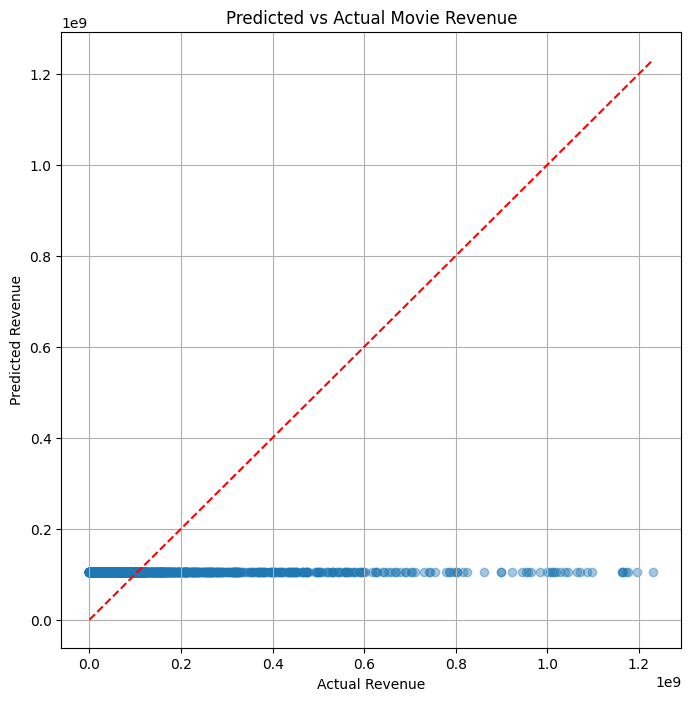

In [9]:
print("Model bazowy - średnia")
mae, rmse, r2 = evaluate_model(y_test, np.full_like(y_test, np.mean(y_train)))
scores.append({
    "model": "baseline",
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
})

## Regresja liniowa

Prosta regresja liniowa tworzy model wyjaśnialny w 74%, MAE jest mniejszy od odchylenia standardowego, ale i tak jest znaczące.

WYNIKI MODELU
R^2 Score: 0.7496
MAE:        $55,693,288.41
RMSE:       $92,490,351.63
std:        $184,818,060.44


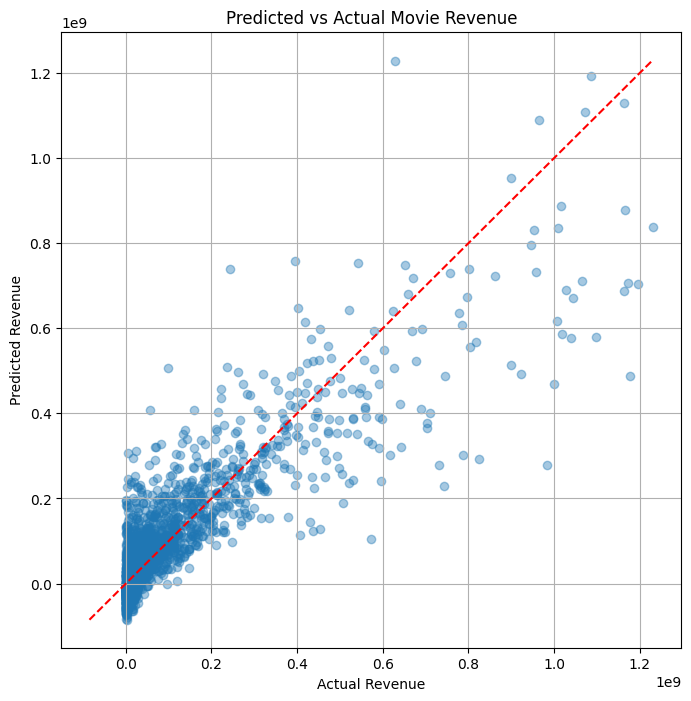

In [10]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
mae, rmse, r2 = evaluate_model(y_test, y_pred)
scores.append({
    "model": "linear regression",
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
})

## RandomForest

Najlepszy uzyskany model, najniższe MAE 28,17 mln.

WYNIKI MODELU
R^2 Score: 0.8810
MAE:        $28,123,977.95
RMSE:       $63,750,370.59
std:        $184,818,060.44


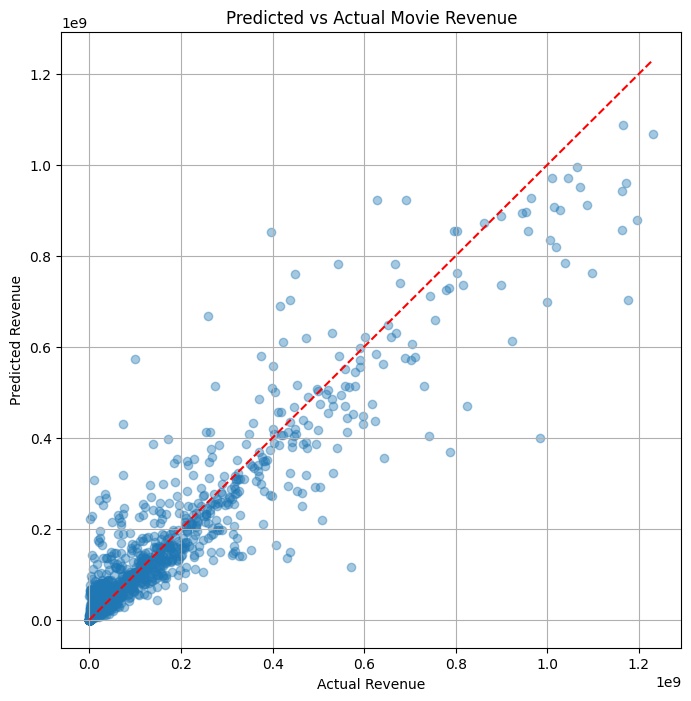

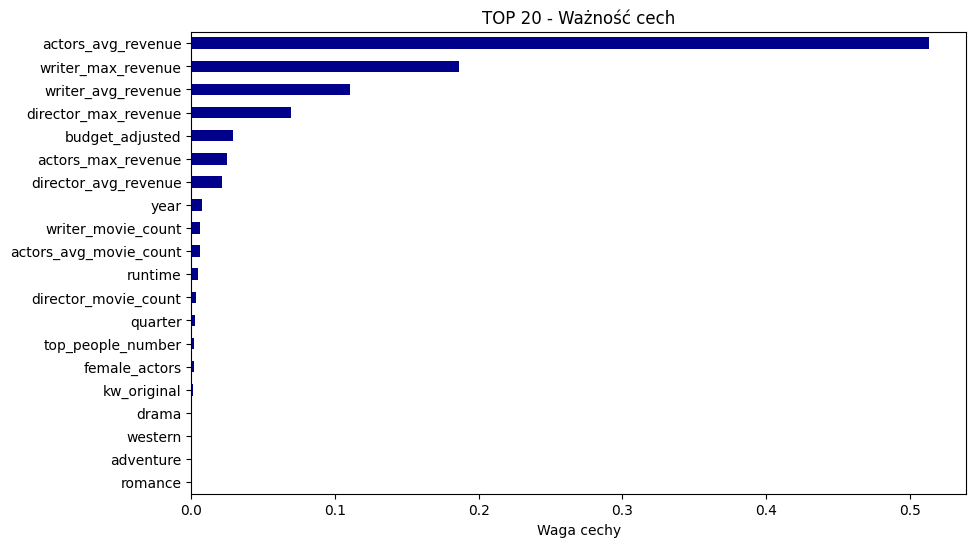

In [12]:
rf = RandomForestRegressor(n_estimators=600, max_depth=13, min_samples_split=2, min_samples_leaf=3, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
evaluate_model(y_test, y_pred)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(10,6))
importances.plot(kind='barh', color='darkblue').invert_yaxis()
plt.title("TOP 20 - Ważność cech")
plt.xlabel("Waga cechy")
plt.show()

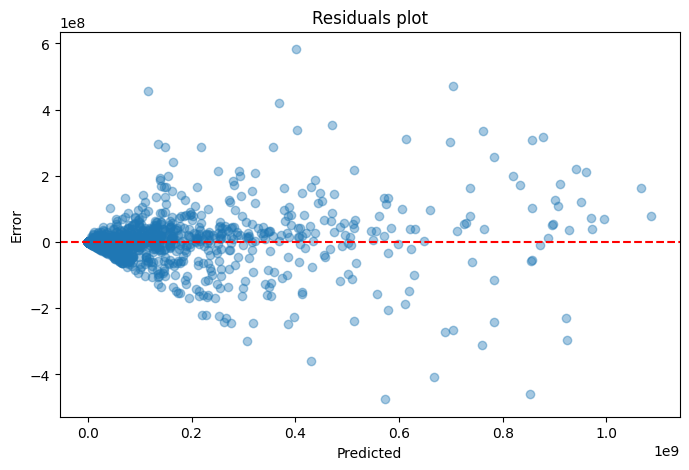

In [13]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals plot")
plt.xlabel("Predicted")
plt.ylabel("Error")
plt.show()

Wybór najbardziej znaczących cech - odrobinę lepszy model

WYNIKI MODELU
R^2 Score: 0.8820
MAE:        $27,988,479.38
RMSE:       $63,484,523.66
std:        $184,818,060.44


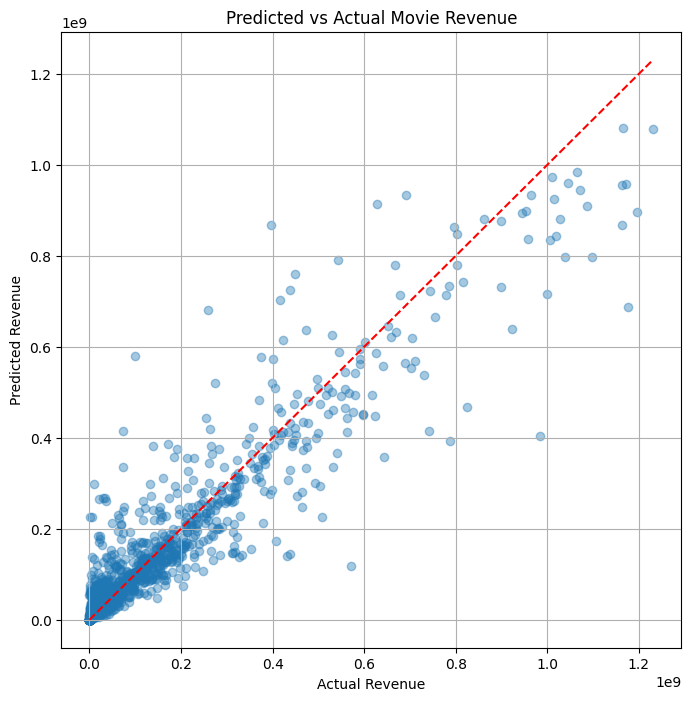

In [14]:
X_train_sample = X_train[importances.index]
X_test_sample = X_test[importances.index]

rf = RandomForestRegressor(n_estimators=600, max_depth=13, min_samples_split=2, min_samples_leaf=3, n_jobs=-1)
rf.fit(X_train_sample, y_train)
y_pred = rf.predict(X_test_sample)
mae, rmse, r2 = evaluate_model(y_test, y_pred)
scores.append({
    "model": "random forest",
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
})

In [15]:
import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

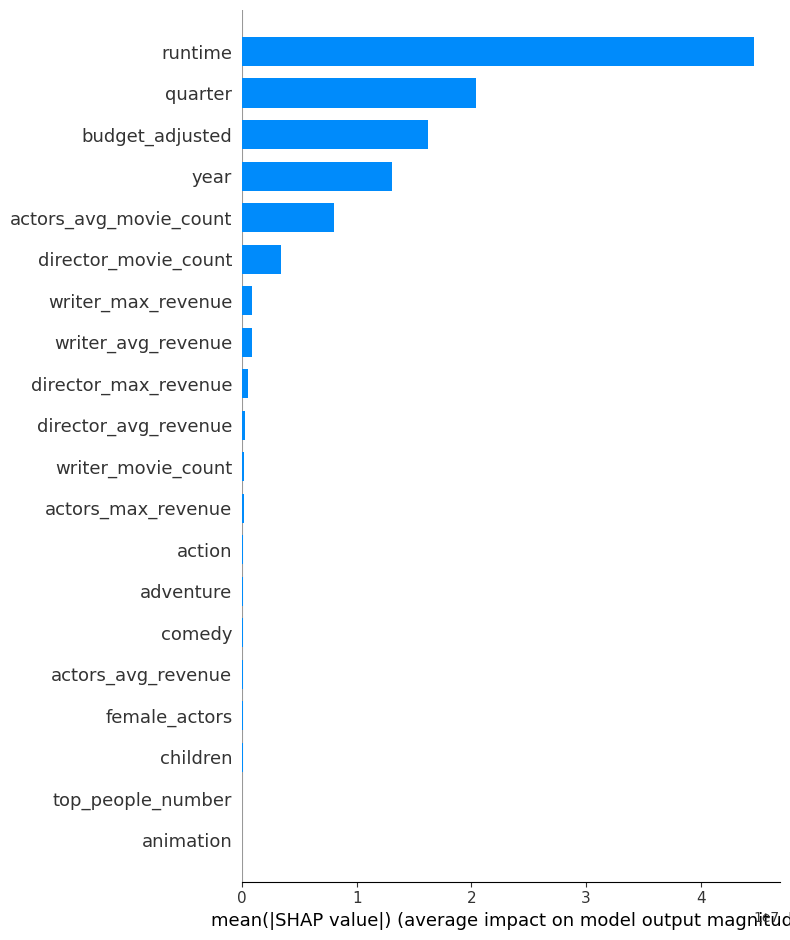

In [22]:
shap.summary_plot(shap_values, X_test,feature_names=X_features,plot_type="bar")

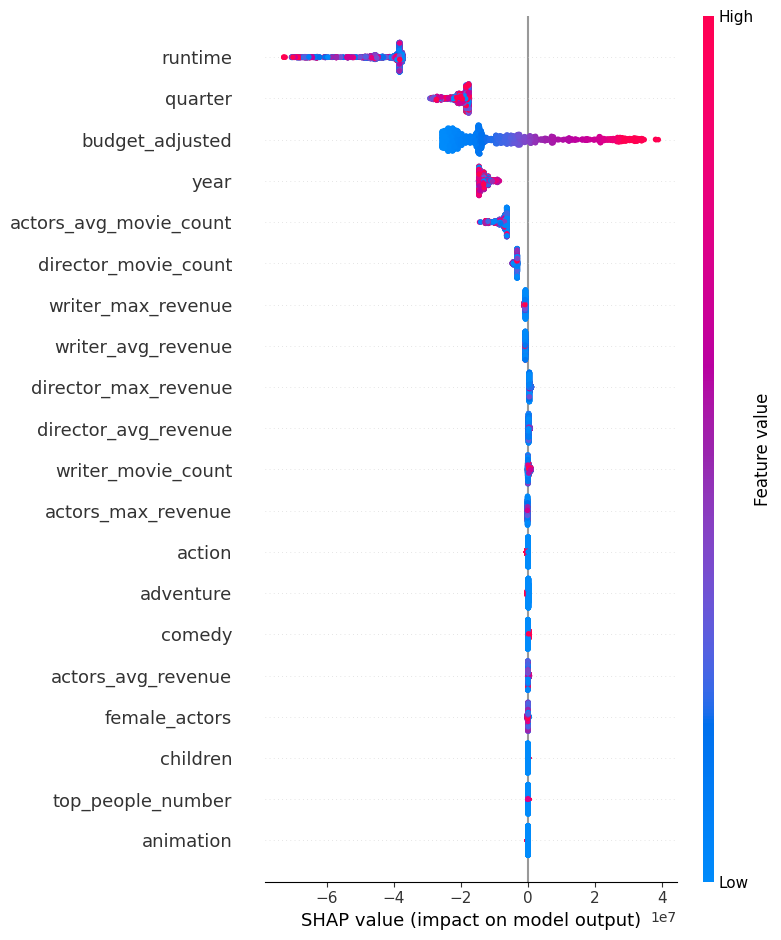

In [23]:
shap.summary_plot(shap_values, X_test, feature_names=X_features)

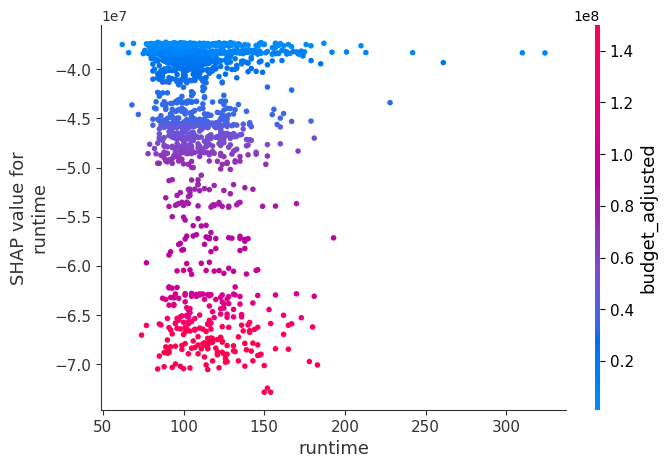

In [24]:
shap.dependence_plot("runtime", shap_values, X_test, feature_names=X_features)

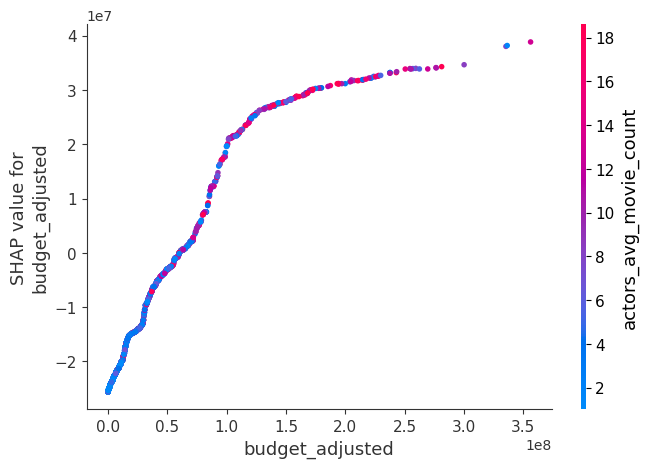

In [26]:
# Interakcja między konkretną cechą a modelem
shap.dependence_plot("budget_adjusted", shap_values, X_test)

Skala logarytmiczna - znaczne pogorszenie wyników

In [27]:
y_log = np.log1p(y)
X_log = X.copy()

X_log['budget_adjusted'] = np.log1p(X_log['budget_adjusted'])
X_log['writer_avg_revenue'] = np.log1p(X_log['writer_avg_revenue'])
X_log['writer_max_revenue'] = np.log1p(X_log['writer_max_revenue'])
X_log['director_avg_revenue'] = np.log1p(X_log['director_avg_revenue'])
X_log['director_max_revenue'] = np.log1p(X_log['director_max_revenue'])
X_log['actors_avg_revenue'] = np.log1p(X_log['actors_avg_revenue'])
X_log['actors_max_revenue'] = np.log1p(X_log['actors_max_revenue'])

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=123)

WYNIKI MODELU
R^2 Score: 0.8708
MAE:        $30,521,423.40
RMSE:       $68,446,863.01
std:        $190,440,968.74


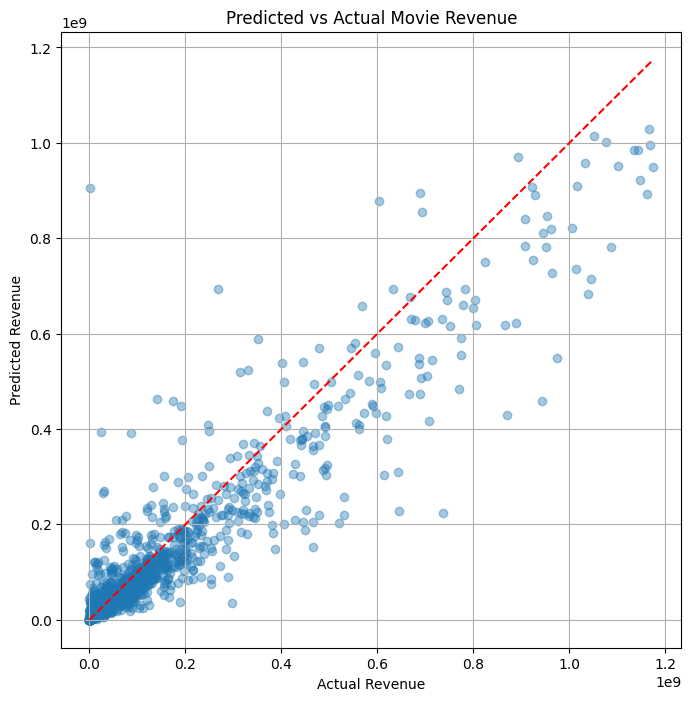

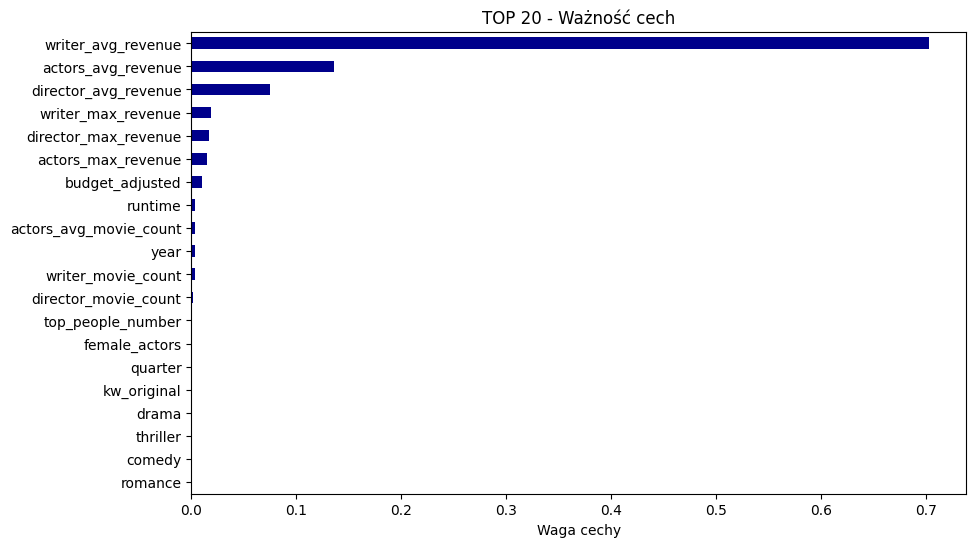

In [28]:
rf = RandomForestRegressor(n_estimators=600, max_depth=13, min_samples_split=2, min_samples_leaf=3, n_jobs=-1)
rf.fit(X_train_log, y_train_log)
y_pred_log = rf.predict(X_test_log)

y_test_real = np.expm1(y_test_log)
y_pred_real = np.expm1(y_pred_log)
mae, rmse, r2 = evaluate_model(y_test_real, y_pred_real)
scores.append({
    "model": "random forest log",
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
})

importances = pd.Series(rf.feature_importances_, index=X_log.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(10,6))
importances.plot(kind='barh', color='darkblue').invert_yaxis()
plt.title("TOP 20 - Ważność cech")
plt.xlabel("Waga cechy")
plt.show()

Wybór najważniejszych cech - brak poprawy

WYNIKI MODELU
R^2 Score: 0.8706
MAE:        $30,432,339.12
RMSE:       $68,497,884.85
std:        $190,440,968.74


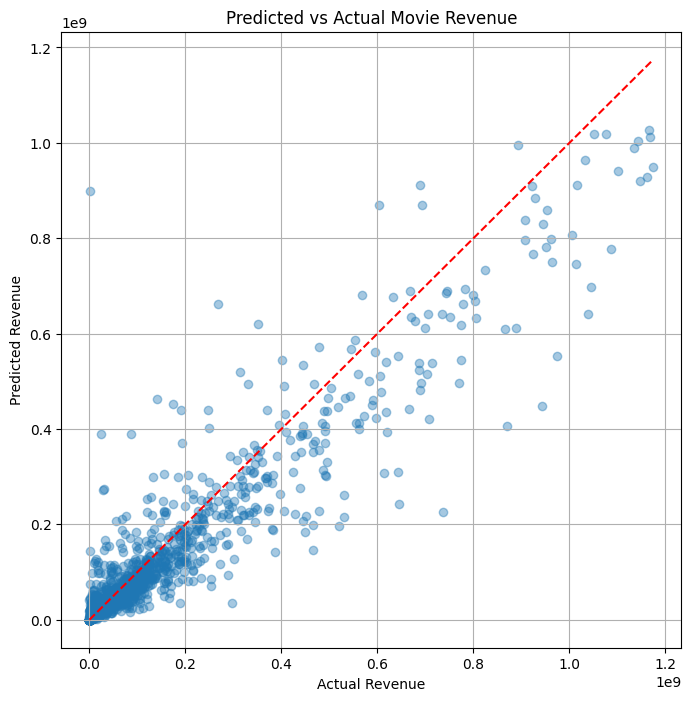

(30432339.124974824, np.float64(68497884.84865583), 0.8706300059375518)

In [29]:
X_train_log_sample = X_train_log[importances.index]
X_test_log_sample = X_test_log[importances.index]

rf = RandomForestRegressor(n_estimators=600, max_depth=13, min_samples_split=2, min_samples_leaf=3, n_jobs=-1)
rf.fit(X_train_log_sample, y_train_log)
y_pred_log = rf.predict(X_test_log_sample)

y_test_real = np.expm1(y_test_log)
y_pred_real = np.expm1(y_pred_log)
evaluate_model(y_test_real, y_pred_real)

## XGBoost

WYNIKI MODELU
R^2 Score: 0.8585
MAE:        $31,852,466.36
RMSE:       $69,526,636.18
std:        $184,818,060.44


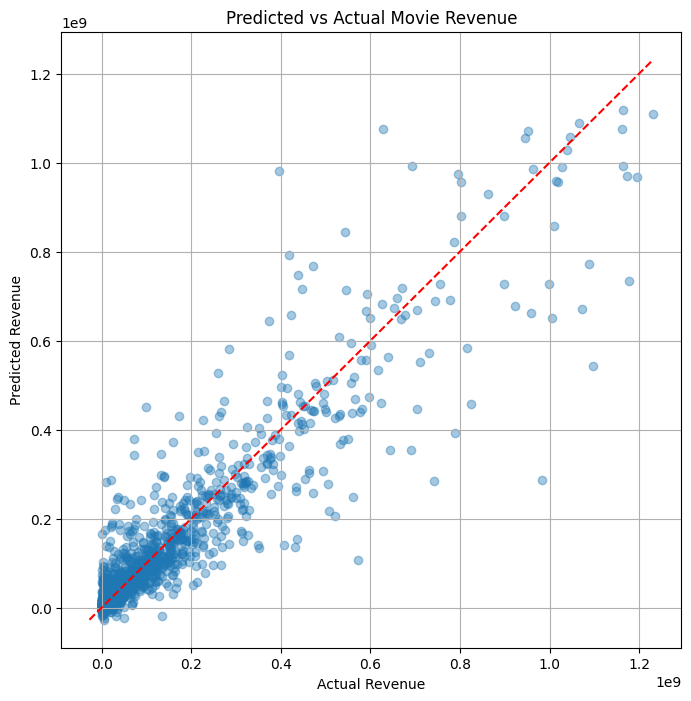

(31852466.357714683, np.float64(69526636.18343872), 0.8584813687595795)

In [30]:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

evaluate_model(y_test, y_pred)

In [31]:
param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.1, 0.2],
    "n_estimators": [200, 500, 800],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0],
    "min_child_weight": [1, 5, 10],
    "gamma": [0, 0.1, 0.3]
}

search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)
print("Best parameters:", search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'subsample': 0.9, 'n_estimators': 800, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 1.0}


Wyniki podobne do Random Forest

WYNIKI MODELU
R^2 Score: 0.8804
MAE:        $28,801,598.39
RMSE:       $63,923,181.48
std:        $184,818,060.44


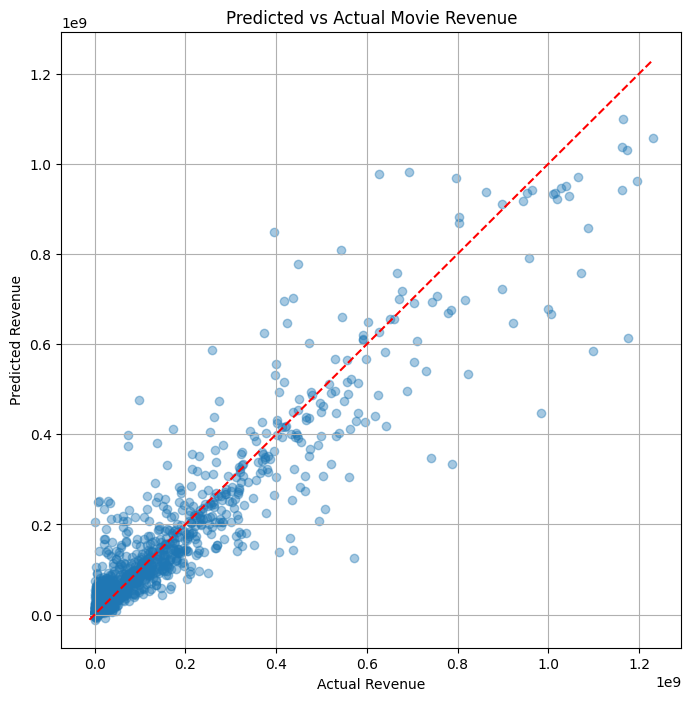

In [32]:
xgb_model = xgb.XGBRegressor(learning_rate=0.03, subsample=0.9, n_estimators=500, min_child_weight=1, max_depth=7, gamma=0.3, colsample_bytree=0.9, objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

mae, rmse, r2 = evaluate_model(y_test, y_pred)
scores.append({
    "model": "xgb",
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
})

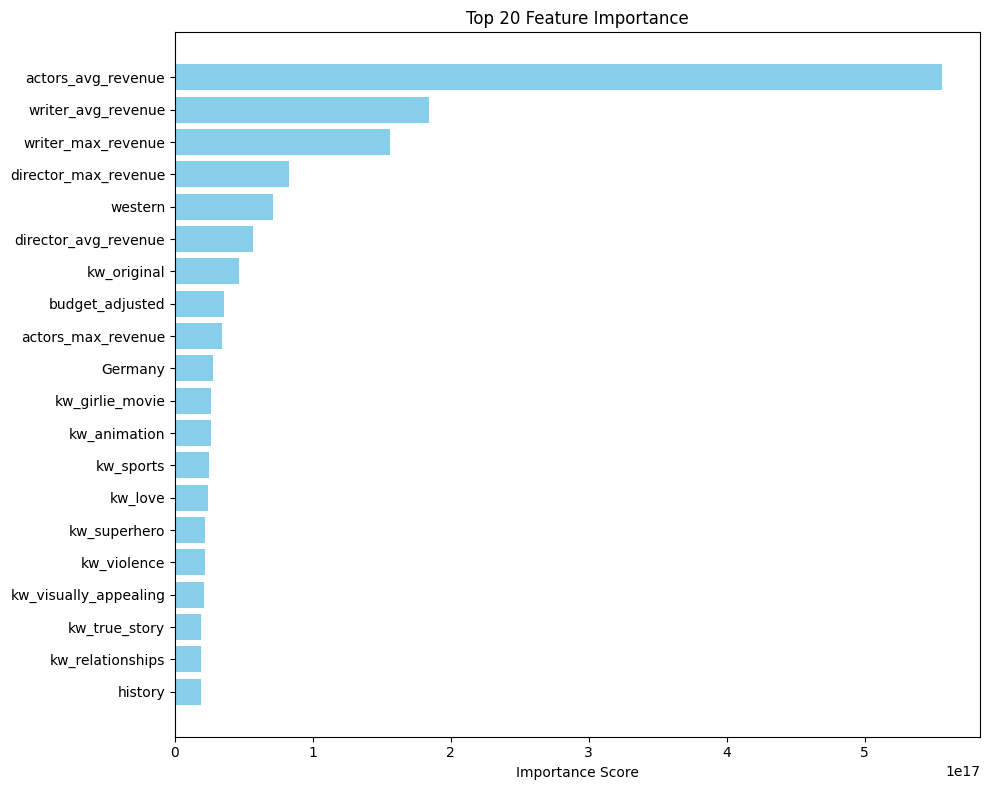

In [33]:
importance = xgb_model.get_booster().get_score(importance_type='gain')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

top_n = 20
plt.figure(figsize=(10, 8))
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance')
plt.tight_layout()
plt.show()

Wybór najważniejszych cech i dalsze przeszukiwanie przestrzeni hiperparametrów nie przynosi znaczącej poprawy

WYNIKI MODELU
R^2 Score: 0.8822
MAE:        $28,441,705.32
RMSE:       $63,437,438.01
std:        $184,818,060.44


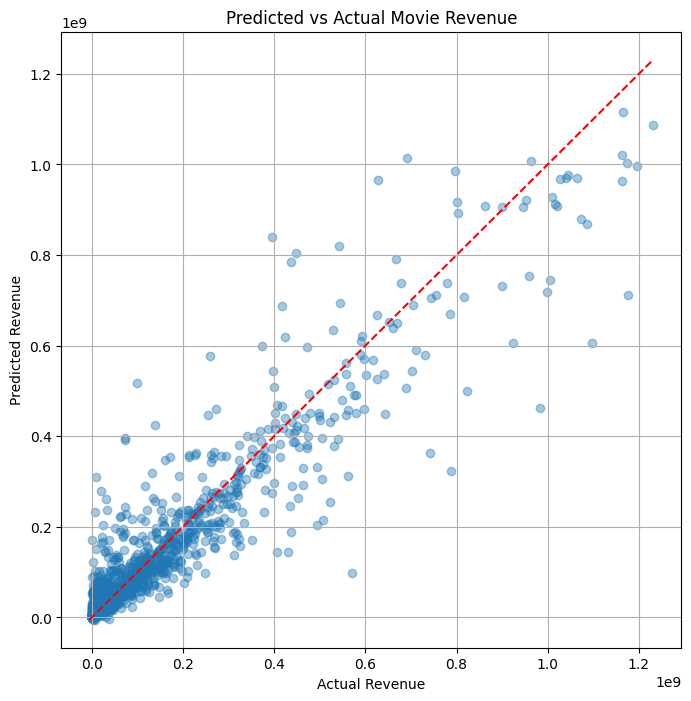

(28441705.31694263, np.float64(63437438.008448295), 0.8821844937160809)

In [34]:
top_features = list(importance_df['Feature'].head(30)[::-1])
xgb_model = xgb.XGBRegressor(learning_rate=0.03, subsample=0.9, n_estimators=500, min_child_weight=1, max_depth=7, gamma=0.3, colsample_bytree=0.9, objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train[top_features], y_train)
y_pred = xgb_model.predict(X_test[top_features])

evaluate_model(y_test, y_pred)

In [35]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test[top_features])

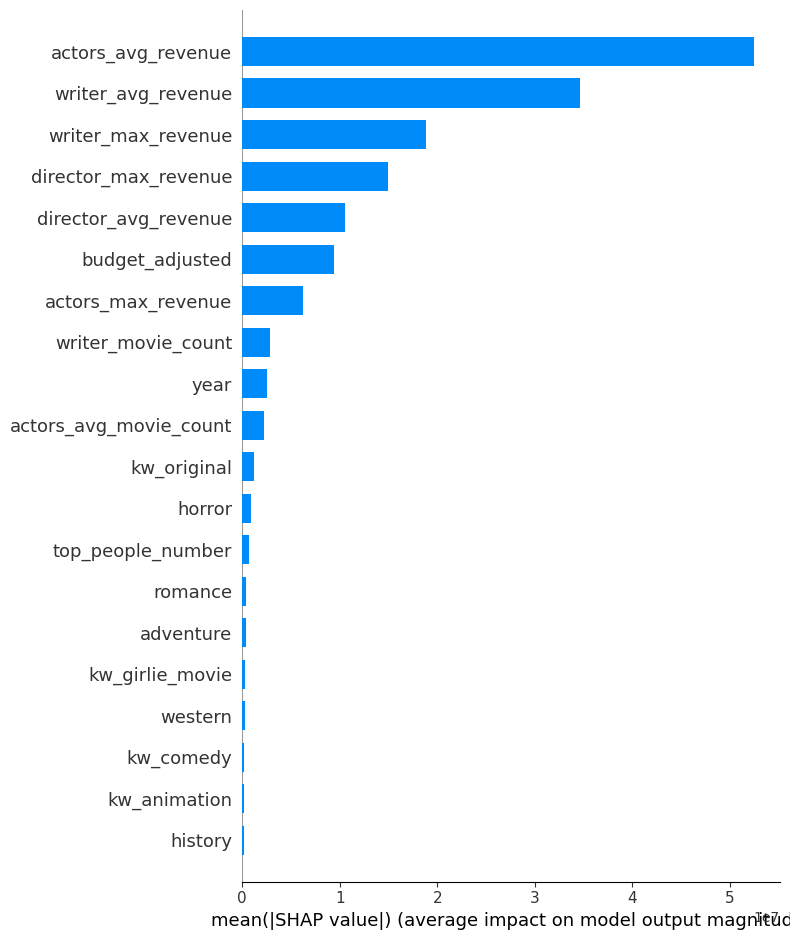

In [36]:
shap.summary_plot(shap_values, X_test[top_features],plot_type="bar")

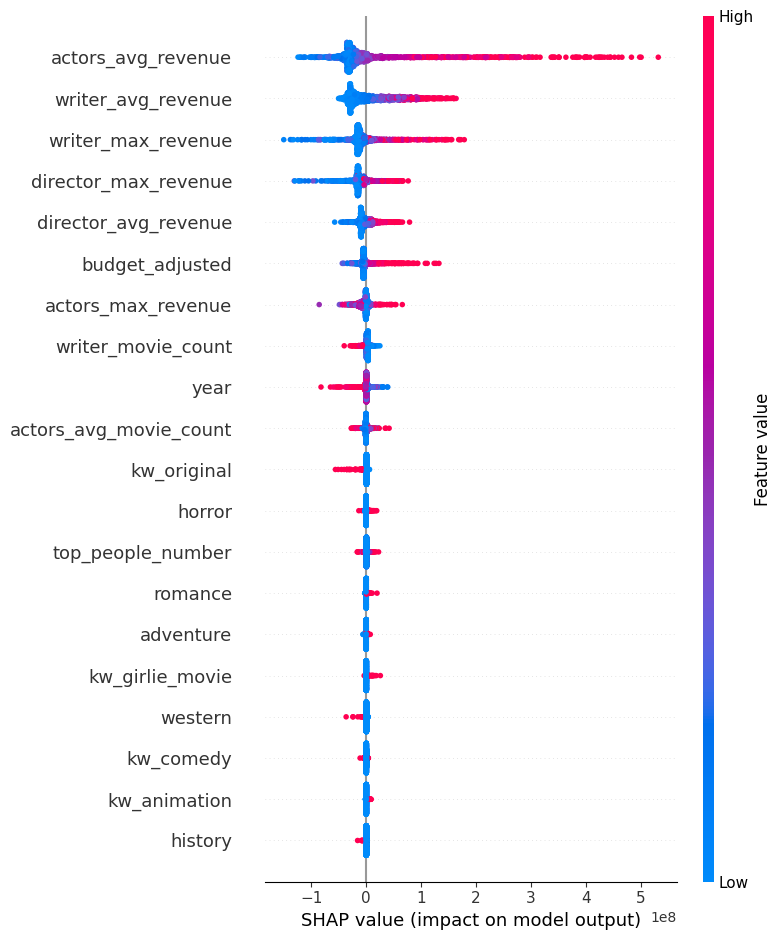

In [37]:
shap.summary_plot(shap_values, X_test[top_features])

In [38]:
param_grid = {
    "max_depth": [7, 10, 12, 15],
    "learning_rate": [0.0001, 0.001, 0.01, 0.03],
    "n_estimators": [500, 600, 700],
    "subsample": [0.9],
    "colsample_bytree": [0.9],
    "min_child_weight": [1],
    "gamma": [0.3]
}


search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)
print("Best parameters:", search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'subsample': 0.9, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.9}


WYNIKI MODELU
R^2 Score: 0.8739
MAE:        $28,736,325.92
RMSE:       $65,621,008.99
std:        $184,818,060.44


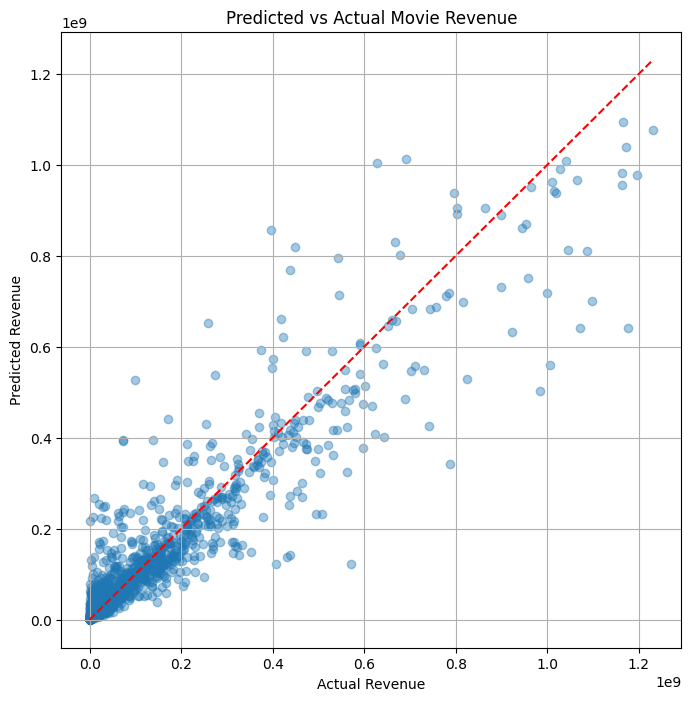

(28736325.92202457, np.float64(65621008.98744947), 0.8739342850702646)

In [39]:
xgb_model = xgb.XGBRegressor(**search.best_params_, objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

evaluate_model(y_test, y_pred)

Skala logarytmiczna - ponowne pogorszenie wyników

WYNIKI MODELU
R^2 Score: 0.8620
MAE:        $31,374,862.52
RMSE:       $70,746,057.80
std:        $190,440,968.74


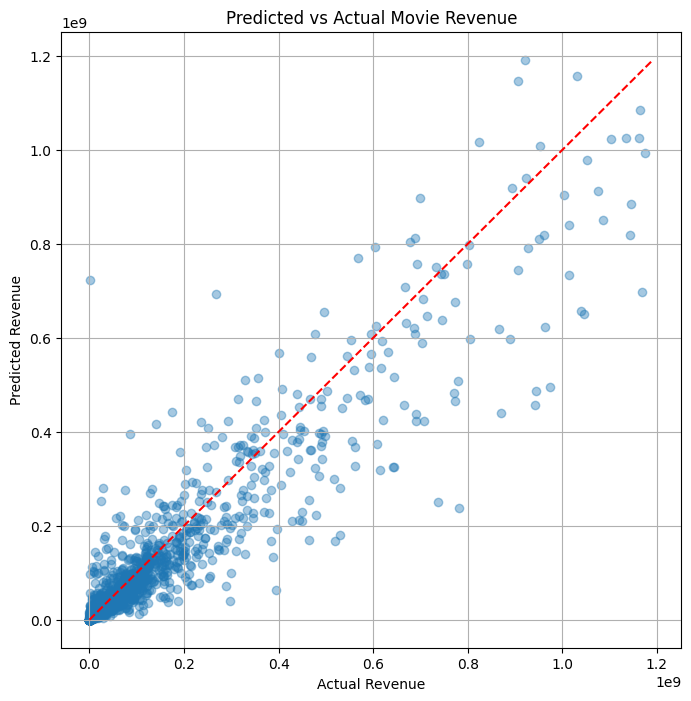

In [40]:
xgb_model = xgb.XGBRegressor(learning_rate=0.03, subsample=0.9, n_estimators=500, min_child_weight=1, max_depth=7, gamma=0.3, colsample_bytree=0.9, objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train_log, y_train_log)
y_pred_log = xgb_model.predict(X_test_log)

y_test_real = np.expm1(y_test_log)
y_pred_real = np.expm1(y_pred_log)
mae, rmse, r2 = evaluate_model(y_test_real, y_pred_real)
scores.append({
    "model": "xgb log",
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
})

Istotność cech wg SHAP

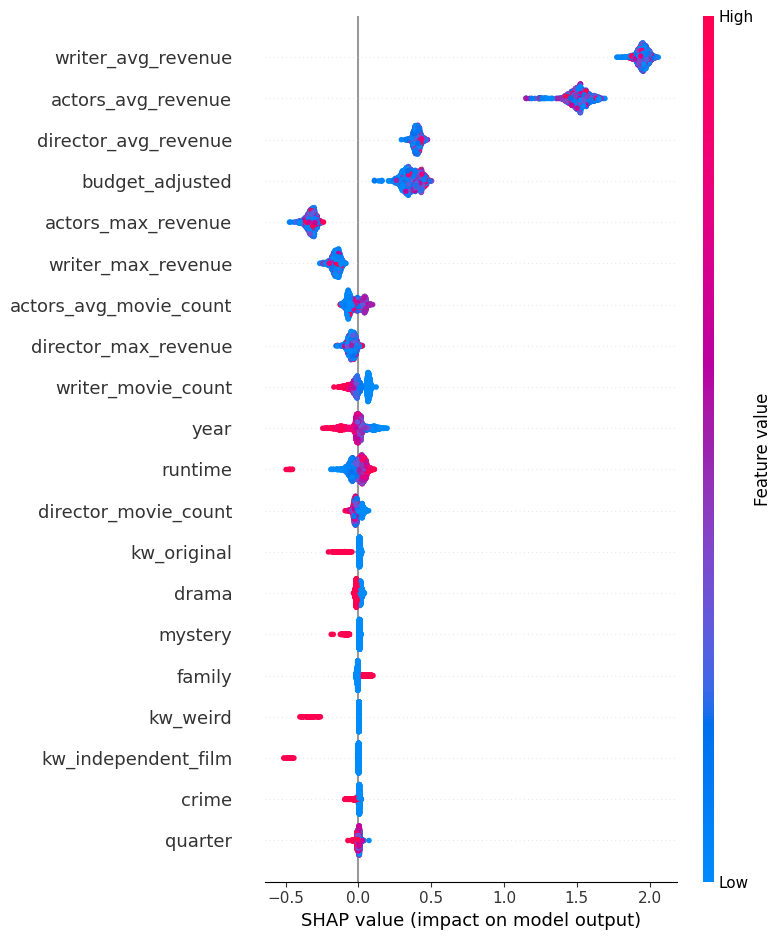

writer_avg_revenue        1.953780
actors_avg_revenue        1.514928
director_avg_revenue      0.401377
budget_adjusted           0.364190
actors_max_revenue        0.324798
writer_max_revenue        0.153054
actors_avg_movie_count    0.047151
director_max_revenue      0.044952
writer_movie_count        0.044415
year                      0.042796
runtime                   0.038045
director_movie_count      0.021423
kw_original               0.017607
drama                     0.015499
mystery                   0.015132
family                    0.012370
kw_weird                  0.009524
kw_independent_film       0.009470
crime                     0.008813
quarter                   0.007446
dtype: float32

In [41]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

mean_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_shap, index=X_test.columns)
top_features = shap_importance.sort_values(ascending=False).head(20)
top_features

Model XGB z cechami wg SHAP - lekkie pogorszenie

WYNIKI MODELU
R^2 Score: 0.8768
MAE:        $28,746,067.09
RMSE:       $64,864,248.21
std:        $184,818,060.44


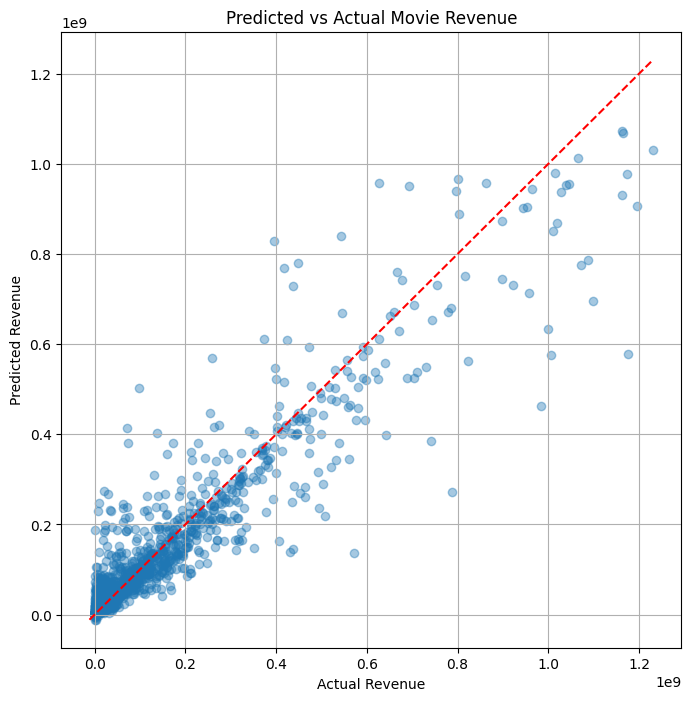

(28746067.09208519, np.float64(64864248.212522924), 0.8768251729124195)

In [42]:
selected_cols = list(top_features.index)

X_train_sel = X_train[selected_cols]
X_test_sel = X_test[selected_cols]

xgb_model = xgb.XGBRegressor(learning_rate=0.03, subsample=0.9, n_estimators=500, min_child_weight=1, max_depth=7, gamma=0.3, colsample_bytree=0.9, objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train_sel, y_train)
y_pred = xgb_model.predict(X_test_sel)

evaluate_model(y_test, y_pred)

## MLP

Wbudowana klasa z regresorem MLP działa lepiej niż własna architektura przedstawiona niżej, ale i tak wyniki są znacznie gorsze od Random Forest i XGB

WYNIKI MODELU
R^2 Score: 0.8574
MAE:        $33,955,910.55
RMSE:       $69,786,119.95
std:        $184,818,060.44


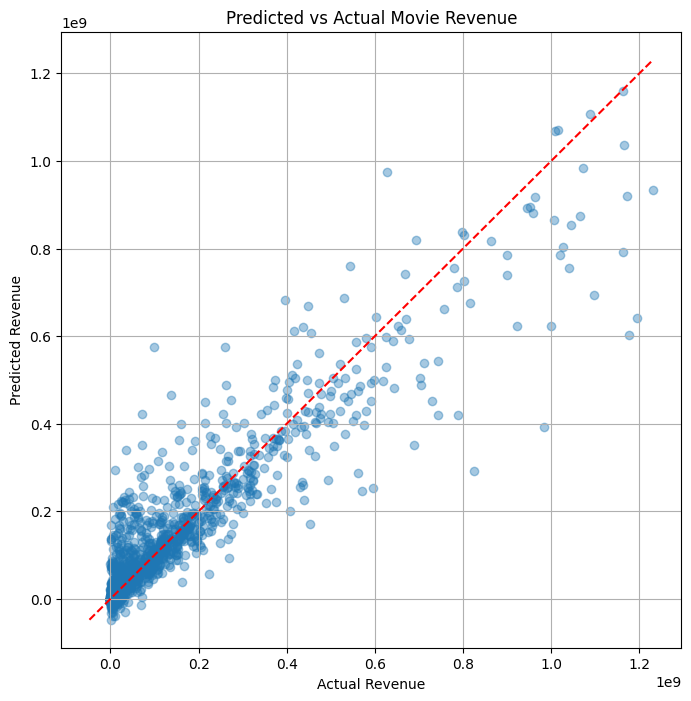

(33955910.55432913, np.float64(69786119.94615233), 0.8574230603316938)

In [43]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(random_state=1, max_iter=2000, tol=0.1)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
evaluate_model(y_test, y_pred)

In [46]:
X_train_summary = shap.kmeans(X_train, 10)
explainer = shap.KernelExplainer(mlp.predict,X_train_summary)
shap_values = explainer.shap_values(X_test)

  0%|          | 0/1801 [00:00<?, ?it/s]

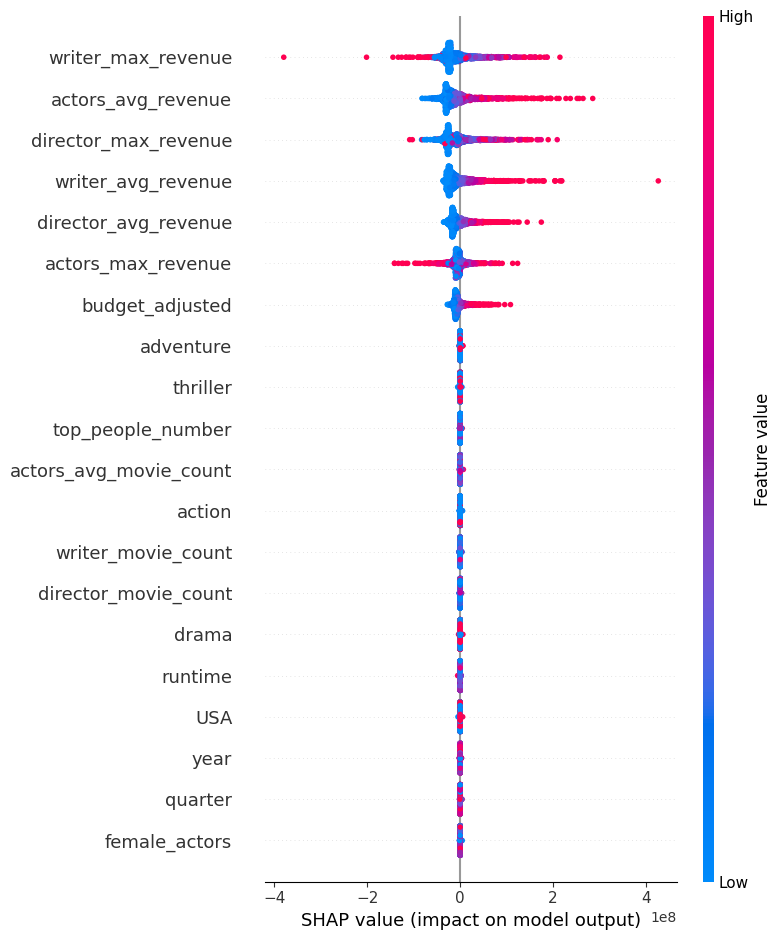

In [47]:
shap.summary_plot(shap_values, X_test)

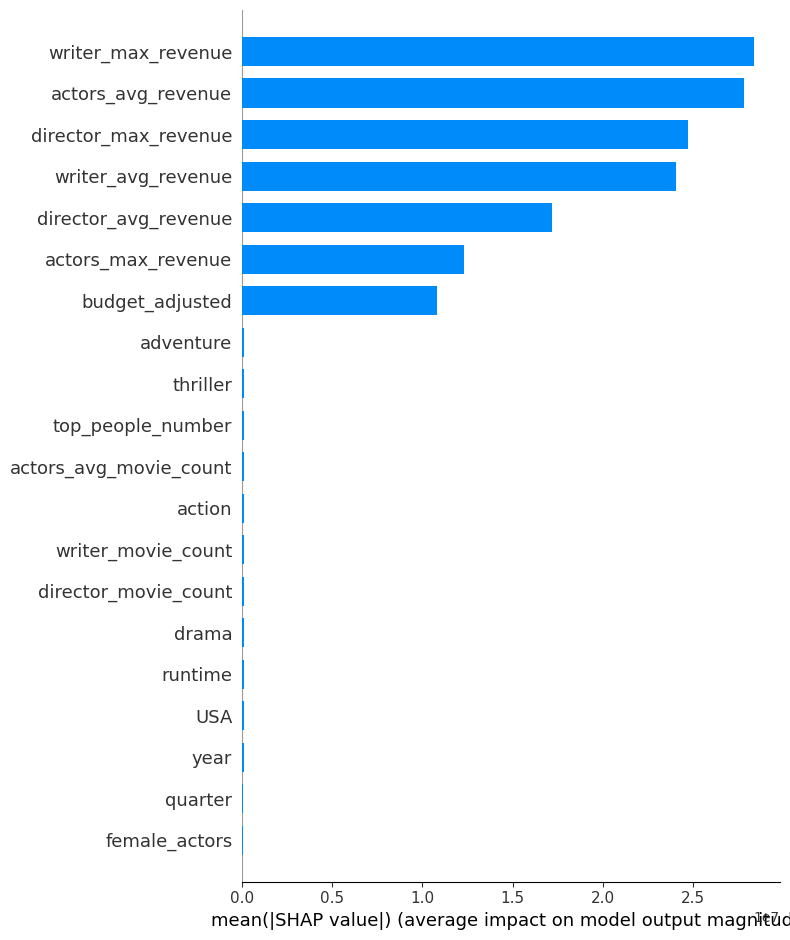

In [56]:
shap.summary_plot(shap_values,X_train,plot_type="bar")

In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

In [49]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

E:\Data_Exploration\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=500,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 44640760498225152.0000 - mae: 106174328.0000 - val_loss: 42024055968104448.0000 - val_mae: 103435488.0000
Epoch 2/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 44639682461433856.0000 - mae: 106172664.0000 - val_loss: 42021779635437568.0000 - val_mae: 103431904.0000
Epoch 3/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 44635469098516480.0000 - mae: 106166000.0000 - val_loss: 42015594882531328.0000 - val_mae: 103422200.0000
Epoch 4/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 44626239213797376.0000 - mae: 106151640.0000 - val_loss: 42003495959658496.0000 - val_mae: 103403232.0000
Epoch 5/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 44610042892124160.0000 - mae: 106126464.0000 - val_loss: 41984125657153536.0000 - val_mae: 103372976.0000
Epoch 6/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 44586304607879168.0000 - mae: 106089328.0000 - val_loss: 41957466795147264.0000 - val_mae: 103331408.000

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
WYNIKI MODELU
R^2 Score: 0.7425
MAE:        $53,229,611.31
RMSE:       $93,777,423.01
std:        $184,818,060.44


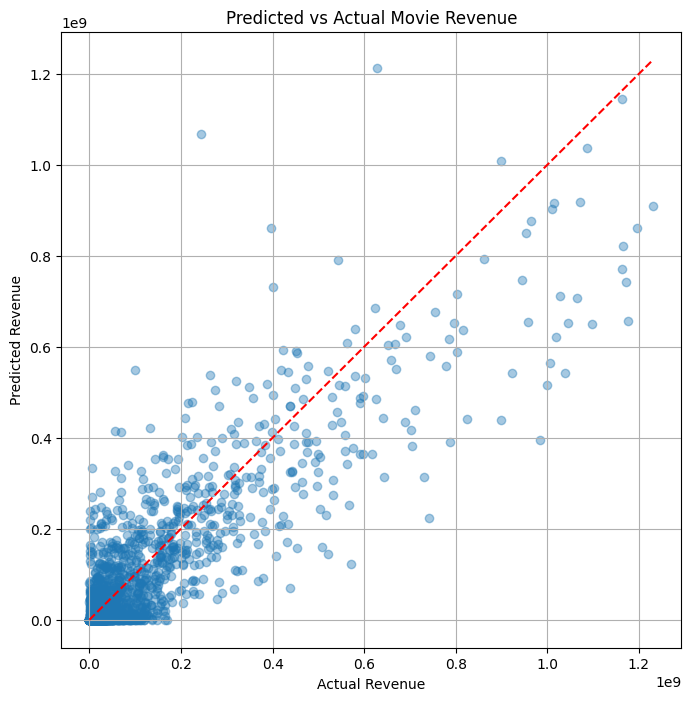

In [52]:
y_pred = model.predict(X_test_scaled)
# y_pred_log = model.predict(X_test_scaled)
# y_pred = np.expm1(y_pred_log).flatten()

mae, rmse, r2 = evaluate_model(y_test, y_pred)
scores.append({
    "model": "mlp",
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
})

Ale nie występuje przeuczenie

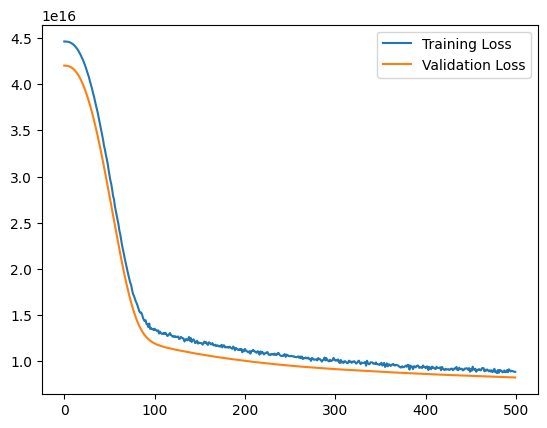

In [53]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

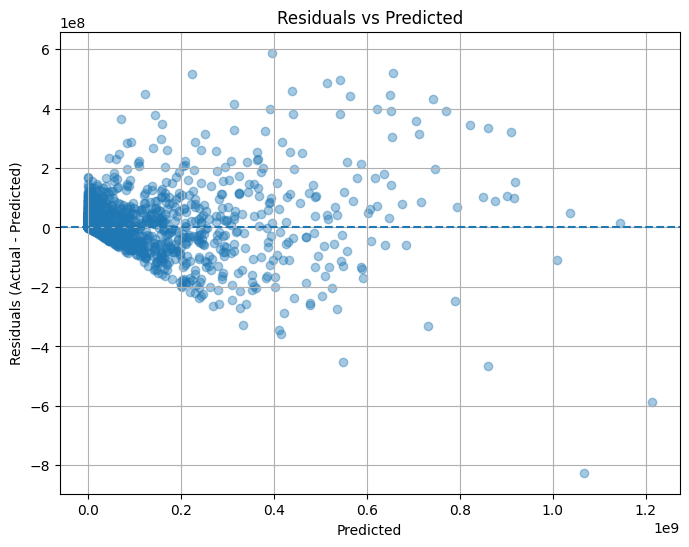

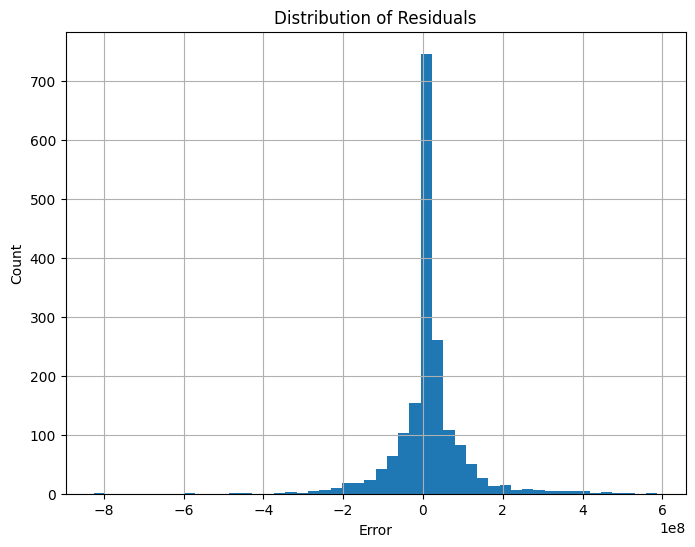

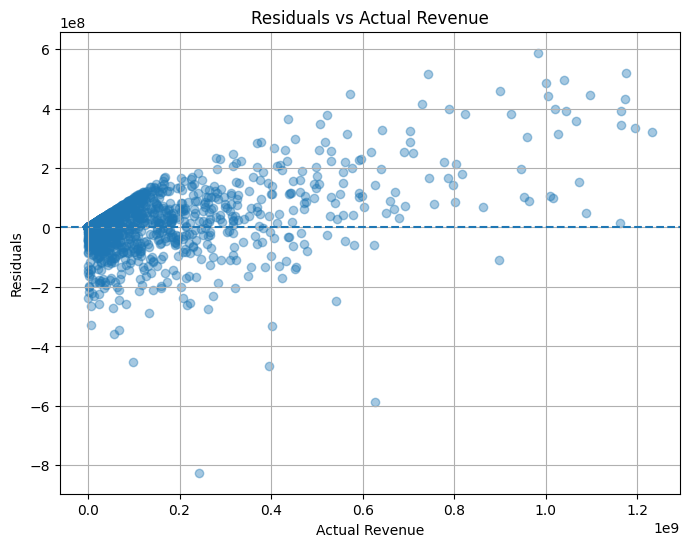

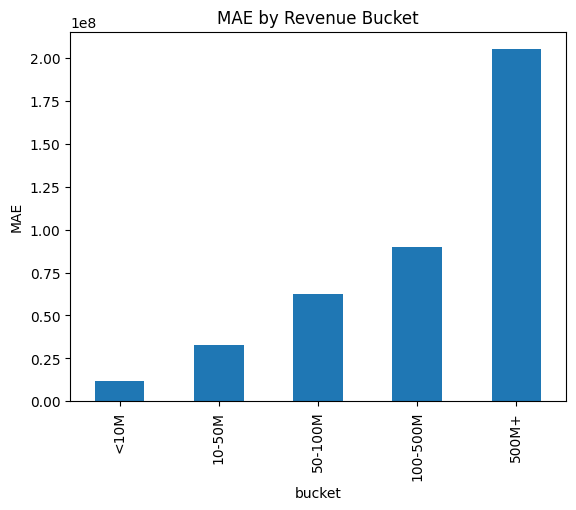

In [57]:
evaluate_model_complex(np.array(y_test).flatten(), np.array(y_pred).flatten())

Skala logarytmiczna - tym razem bardzo znaczne pogorszenie wyników

In [59]:
scaler = StandardScaler()
X_train_scaled_log = scaler.fit_transform(X_train_log)
X_test_scaled_log = scaler.transform(X_test_log)

In [63]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled_log,
    y_train_log,
    epochs=500,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 134590.2656 - mae: 238.6085 - val_loss: 3006.5891 - val_mae: 13.4231
Epoch 2/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 101452.1641 - mae: 233.3459 - val_loss: 1959.1733 - val_mae: 22.7838
Epoch 3/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 103078.4297 - mae: 232.2664 - val_loss: 2522.6528 - val_mae: 14.4097
Epoch 4/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 91146.7188 - mae: 224.3297 - val_loss: 9594.5527 - val_mae: 14.8873
Epoch 5/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 109172.8750 - mae: 221.0263 - val_loss: 18473.4082 - val_mae: 14.5778
Epoch 6/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 79019.6016 - mae: 215.7208 - val_loss: 21010.1133 - val_mae: 17.6712
Epoch 7/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 74563.0938 - mae: 213.6089 - val_loss: 23725.6953 - val_mae: 21.5685
Epoch 8/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 72993.3359 - mae: 211.0116 - 

In [64]:
y_pred_log = model.predict(X_test_scaled_log)
y_test_real = np.expm1(y_test_log)
y_pred_real = np.expm1(y_pred_log)

mae, rmse, r2 = evaluate_model(y_test_real, y_pred_real)
scores.append({
    "model": "mlp log",
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
})

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


C:\Users\klang\AppData\Local\Temp\ipykernel_14192\1174005824.py:3: RuntimeWarning: overflow encountered in expm1
  y_pred_real = np.expm1(y_pred_log)


ValueError: Input contains infinity or a value too large for dtype('float64').

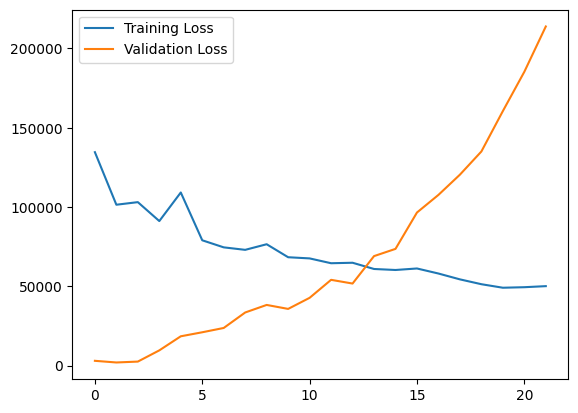

In [65]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [66]:
scores = sorted(scores, key=lambda x: x['mae'])
for model in scores:
    for k, v in model.items():
        if k == "r2":
            print(f"{k}: {v:.4f}")
        elif k in ("mae", "rmse"):
            print(f"{k}: ${v:,.2f}")
        elif k == "model":
            print(v.upper())
        else:
            print(f"{k}: {v}")
    print()

RANDOM FOREST
r2: 0.8820
mae: $27,988,479.38
rmse: $63,484,523.66

XGB
r2: 0.8804
mae: $28,801,598.39
rmse: $63,923,181.48

RANDOM FOREST LOG
r2: 0.8708
mae: $30,521,423.40
rmse: $68,446,863.01

XGB LOG
r2: 0.8620
mae: $31,374,862.52
rmse: $70,746,057.80

MLP
r2: 0.7425
mae: $53,229,611.31
rmse: $93,777,423.01

LINEAR REGRESSION
r2: 0.7496
mae: $55,693,288.41
rmse: $92,490,351.63

BASELINE
r2: -0.0001
mae: $117,578,576.15
rmse: $184,825,693.94



Najlepszy model - Random Forest z 20 najważniejszymi cechami po przeszukaniu przestrzeni hiperparametrów. Model wyjaśnia 88% danych (R2 = 0.8836), a więc jest to bardzo wysoki wynik. MAE na poziomie 28 mln $ również jest satysfakcjonującym wynikiem biorąc pod uwagę to, że odchylenie standardowe danych wynosi 184 mln, a MAE modelu bazowego zwracającego zawsze średnią wynosi 117 mln. Model wnosi dużo informacji i pomaga dobrze oszacować poziom sukcesu filmu. Błędy wydają się być stosunkowo duże, bo przychód w zbiorze danych ma ogromny zakres i niektóre filmy zarabiają ponad miliard a niektóre poniżej 100 000. Pomimo to, porównując wyniki z publikacjami naukowymi, model sprawdza się dobrze (w literaturze MAE na poziomie ok. 12-21 mln dolarów w zależności od modelu).

Link do artykułu: https://www.researchgate.net/publication/399361049_PREDICTIVE_MODELING_OF_BOX_OFFICE_SUCCESS_USING_MACHINE_LEARNING_AND_HISTORICAL_MOVIE_DATA

# LightGBM

Nie dodałem go zostawiamy na następny raz???????????????

R^2 Score: 0.8768

MAE:        $28,627,370.49

RMSE:       $64,864,828.46

std:        $184,818,060.44

In [71]:
import lightgbm as lgb
param_dist = {
    'n_estimators': [500, 1000, 2000],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': np.arange(20, 150, 10),
    'max_depth': [-1, 5, 10, 15],
    'min_child_samples': [5, 10, 20, 50],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
}

# 2. Inicjalizacja modelu bazowego
lgbm = lgb.LGBMRegressor(random_state=42, verbosity=-1)

# 3. RandomizedSearch (n_iter=50 oznacza 50 losowych prób)
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    random_state=42
)

# Dopasowanie do pełnych danych treningowych
random_search.fit(X_train, y_train)

best_lgbm = random_search.best_estimator_
print(f"Najlepsze parametry: {random_search.best_params_}")

KeyboardInterrupt: 

In [68]:
# 1. Pobieramy ważność cech
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_lgbm.feature_importances_
}).sort_values(by='importance', ascending=False)

# 2. Wybieramy top 20 nazw cech
top_20_features = feature_importances.head(20)['feature'].tolist()

print("Wybrane Top 20 cech:")
print(top_20_features)

# 3. Filtrujemy zbiory danych
X_train_reduced = X_train[top_20_features]
X_test_reduced = X_test[top_20_features]

Wybrane Top 20 cech:
['writer_max_revenue', 'actors_avg_revenue', 'actors_max_revenue', 'budget_adjusted', 'writer_avg_revenue', 'actors_avg_movie_count', 'runtime', 'director_max_revenue', 'director_avg_revenue', 'year', 'writer_movie_count', 'director_movie_count', 'female_actors', 'quarter', 'top_people_number', 'comedy', 'drama', 'action', 'USA', 'adventure']


In [69]:
# 1. Tworzymy nowy model z tymi samymi parametrami
final_model_reduced = lgb.LGBMRegressor(**random_search.best_params_, random_state=42)

# 2. Trenujemy na zredukowanym zbiorze
final_model_reduced.fit(X_train_reduced, y_train)

# 3. Predykcja i metryki
y_pred_reduced = final_model_reduced.predict(X_test_reduced)

print(f"\n--- Metryki modelu po redukcji (20 cech) ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred_reduced):.4f}")
print(f"R2: {r2_score(y_test, y_pred_reduced):.4f}")


--- Metryki modelu po redukcji (20 cech) ---
MAE: 28627370.4915
R2: 0.8768


WYNIKI MODELU
R^2 Score: 0.8768
MAE:        $28,627,370.49
RMSE:       $64,864,828.46
std:        $184,818,060.44


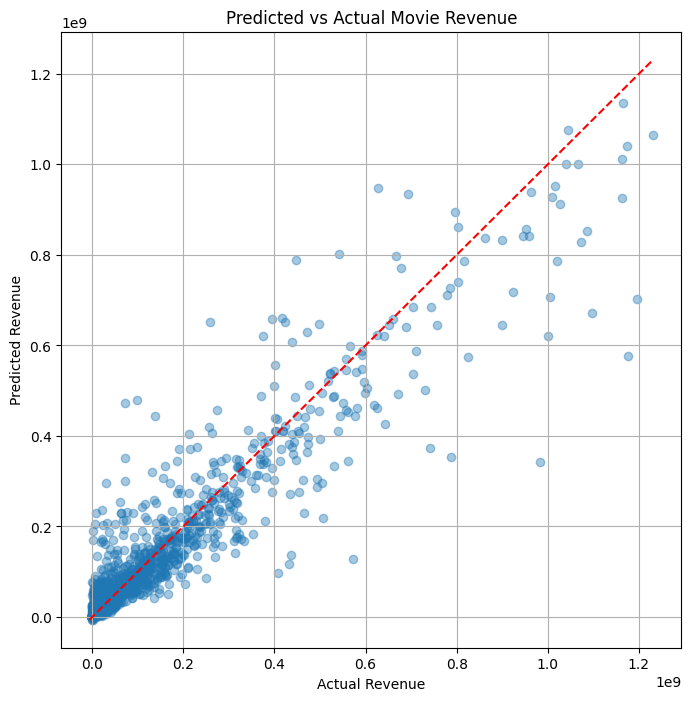

(28627370.49153554, np.float64(64864828.45576354), 0.8768229691813203)

In [70]:
evaluate_model(y_test, y_pred_reduced)

# Wykresy porównań modeli

In [72]:
scores

[{'model': 'random forest',
  'r2': 0.882009534601742,
  'mae': 27988479.381392423,
  'rmse': np.float64(63484523.66302681)},
 {'model': 'xgb',
  'r2': 0.8803733482984284,
  'mae': 28801598.388194863,
  'rmse': np.float64(63923181.48307877)},
 {'model': 'random forest log',
  'r2': 0.8708226611462153,
  'mae': 30521423.403782252,
  'rmse': np.float64(68446863.0060826)},
 {'model': 'xgb log',
  'r2': 0.8619985259854875,
  'mae': 31374862.515700787,
  'rmse': np.float64(70746057.80038646)},
 {'model': 'mlp',
  'r2': 0.742541181489454,
  'mae': 53229611.30623334,
  'rmse': np.float64(93777423.0120431)},
 {'model': 'linear regression',
  'r2': 0.7495597984591578,
  'mae': 55693288.40650143,
  'rmse': np.float64(92490351.63392371)},
 {'model': 'baseline',
  'r2': -8.260727481679275e-05,
  'mae': 117578576.14997984,
  'rmse': np.float64(184825693.9425297)}]

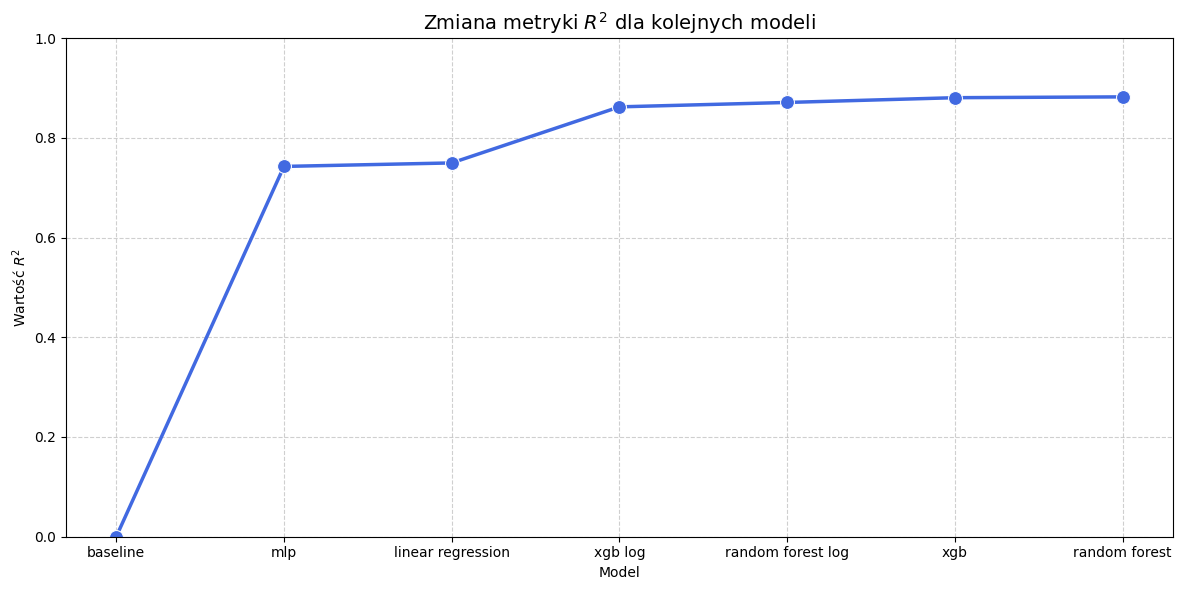

In [93]:
import seaborn as sns
df = pd.DataFrame(scores)
df_melted = df.melt(id_vars='model', var_name='Metric', value_name='Value')

# 3. Tworzenie wykresu
plt.figure(figsize=(12, 6))
df = df.sort_values('r2', ascending=True)
sns.lineplot(data=df, x='model', y='r2', marker='o', markersize=10, linewidth=2.5, color='royalblue')

# Estetyka wykresu
plt.title('Zmiana metryki $R^2$ dla kolejnych modeli', fontsize=14)
plt.ylabel('Wartość $R^2$')
plt.xlabel('Model')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1) # Zakładając standardową skalę R2 (opcjonalne)

plt.tight_layout()
plt.show()

In [80]:
df

,model,r2,mae,rmse
0,random forest,0.882010,2.798848e+07,6.348452e+07
1,xgb,0.880373,2.880160e+07,6.392318e+07
2,random forest log,0.870823,3.052142e+07,6.844686e+07
3,xgb log,0.861999,3.137486e+07,7.074606e+07
4,mlp,0.742541,5.322961e+07,9.377742e+07
5,linear regression,0.749560,5.569329e+07,9.249035e+07
6,baseline,-0.000083,1.175786e+08,1.848257e+08


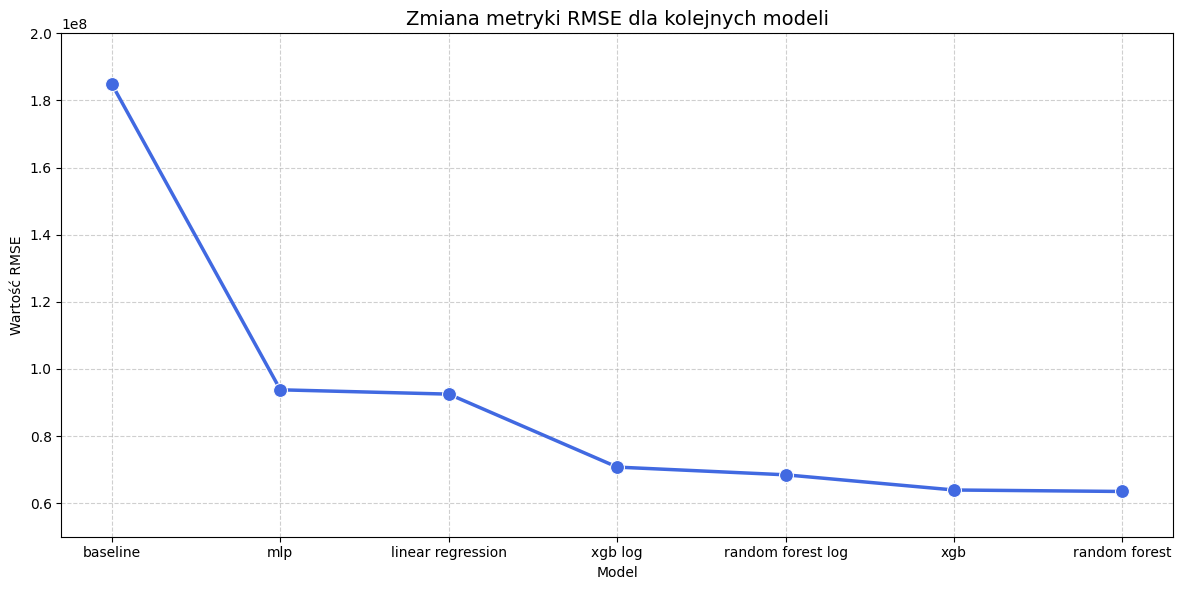

In [98]:
plt.figure(figsize=(12, 6))
df = df.sort_values('rmse', ascending=False)
sns.lineplot(data=df, x='model', y='rmse', marker='o', markersize=10, linewidth=2.5, color='royalblue')

# Estetyka wykresu
plt.title('Zmiana metryki RMSE dla kolejnych modeli', fontsize=14)
plt.ylabel('Wartość RMSE')
plt.xlabel('Model')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(5e7, 2e8)

plt.tight_layout()
plt.show()

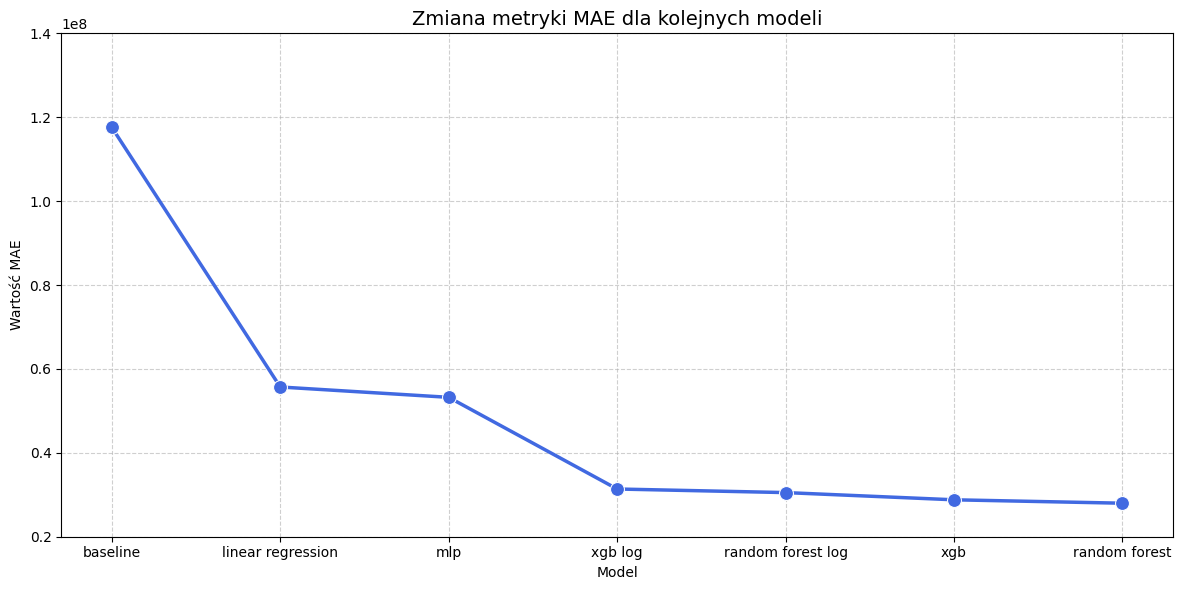

In [97]:
plt.figure(figsize=(12, 6))
df = df.sort_values('mae', ascending=False)
sns.lineplot(data=df, x='model', y='mae', marker='o', markersize=10, linewidth=2.5, color='royalblue')

# Estetyka wykresu
plt.title('Zmiana metryki MAE dla kolejnych modeli', fontsize=14)
plt.ylabel('Wartość MAE')
plt.xlabel('Model')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(2e7, 1.4e8)

plt.tight_layout()
plt.show()